# Loss curve generation for the paper

In [61]:
from pathlib import Path
import json
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import numpy as np

In [34]:
TRAINER_HISTORIES_PATH = Path("../Data/training_histories")
HISTORY_FOCAL_LOSS_PATH = (
    TRAINER_HISTORIES_PATH / "trainer_state_hard_labels_with_focal_loss.json"
)
HISTORY_HARD_LABELS_WITH_BACKGROUND_MINIBATCH_PATH = (
    TRAINER_HISTORIES_PATH
    / "trainer_state_hard_labels_with_rejection_minibatch_balancing.json"
)
HISTORY_HARD_LABELS_WITHOUT_BACKGROUND_PATH = (
    TRAINER_HISTORIES_PATH / "trainer_state_hard_labels_without_background.json"
)
HISTORY_SOFT_LABELS_PATH = (
    TRAINER_HISTORIES_PATH / "trainer_state_methylbert_soft_labels.json"
)

In [35]:
with open(HISTORY_FOCAL_LOSS_PATH, "r") as f:
    history_focal_loss = json.load(f)
with open(HISTORY_HARD_LABELS_WITH_BACKGROUND_MINIBATCH_PATH, "r") as f:
    history_hard_labels_with_background_minibatch = json.load(f)
with open(HISTORY_HARD_LABELS_WITHOUT_BACKGROUND_PATH, "r") as f:
    history_hard_labels_without_background = json.load(f)
with open(HISTORY_SOFT_LABELS_PATH, "r") as f:
    history_soft_labels = json.load(f)

In [79]:
history_hard_labels_without_background

{'best_global_step': 250,
 'best_metric': 3.6535236835479736,
 'best_model_checkpoint': '/data/dmytro/Experiments/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_no_data_leak_d041_postfiltered_min_length_50_hard_labels_WITHOUT_BG/checkpoint-250',
 'epoch': 0.47501759324419424,
 'eval_steps': 50,
 'global_step': 2700,
 'is_hyper_param_search': False,
 'is_local_process_zero': True,
 'is_world_process_zero': True,
 'log_history': [{'epoch': 0.008796622097114707,
   'grad_norm': 0.8962720632553101,
   'learning_rate': 0.000196,
   'loss': 3.4095,
   'loss_ce': 3.4095420455932617,
   'step': 50},
  {'epoch': 0.008796622097114707,
   'eval_accuracy': 0.07931743789182685,
   'eval_f1': 0.0037686418978595693,
   'eval_loss': 3.6926164627075195,
   'eval_loss_ce': 3.692698611434843,
   'eval_matthews_correlation': 0.0,
   'eval_precision': 0.002033780458764791,
   'eval_recall': 0.02564102564102564,
   'eval_runtime': 763.6968,
   'eval_sam

In [80]:
def process_train_logs(log_history):
    steps = []
    train_losses = []
    train_losses_ce = []
    eval_losses = []
    eval_losses_ce = []
    eval_f1 = []
    eval_mcc = []
    eval_precision = []
    eval_recall = []
    for elt in log_history:
        if "eval_loss" in elt:
            steps.append(elt["step"])
            eval_losses.append(elt["eval_loss"])
            if "eval_loss_ce" in elt:
                eval_losses_ce.append(elt["eval_loss_ce"])
            eval_f1.append(elt["eval_f1"])
            eval_mcc.append(elt["eval_matthews_correlation"])
            eval_precision.append(elt["eval_precision"])
            eval_recall.append(elt["eval_recall"])
        else:
            train_losses.append(elt["loss"])
            if "loss_ce" in elt:
                train_losses_ce.append(elt["loss_ce"])
    return {
        "steps": steps,
        "train_loss": train_losses,
        "train_loss_ce": train_losses_ce,
        "eval_loss": eval_losses,
        "eval_loss_ce": eval_losses_ce,
        "eval_f1": eval_f1,
        "eval_mcc": eval_mcc,
        "eval_precision": eval_precision,
        "eval_recall": eval_recall,
    }

In [81]:
hist_focal_loss = process_train_logs(history_focal_loss["log_history"])
hist_hard_labels_with_background_minibatch = process_train_logs(
    history_hard_labels_with_background_minibatch["log_history"]
)
hist_hard_labels_without_background = process_train_logs(
    history_hard_labels_without_background["log_history"]
)
hist_soft_labels = process_train_logs(history_soft_labels["log_history"])

Plot the CE losses for the different training runs. This will be used in the paper to show the difference in convergence between the different methods.

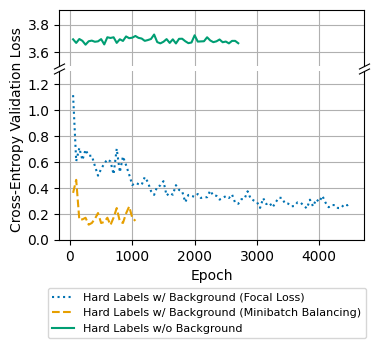

In [104]:
# aggregate the data
model_names = ["focal_loss", "hard_w_bg", "hard_wo_bg"]
histories_per_model = {
    "focal_loss": hist_focal_loss,
    "hard_w_bg": hist_hard_labels_with_background_minibatch,
    "hard_wo_bg": hist_hard_labels_without_background,
}
legend_labels = {
    "focal_loss": "Hard Labels w/ Background (Focal Loss)",
    "hard_w_bg": "Hard Labels w/ Background (Minibatch Balancing)",
    "hard_wo_bg": "Hard Labels w/o Background",
}
# Colorblind-safe palette (Wong, 2011)
colors = {
    "focal_loss": "#0072B2",  # blue
    "hard_w_bg": "#E69F00",  # orange
    "hard_wo_bg": "#009E73",  # green
}
linestyles = {"focal_loss": ":", "hard_w_bg": "--", "hard_wo_bg": "-"}
markers = {"focal_loss": "o", "hard_w_bg": "s", "hard_wo_bg": "^"}
# Subsample factor per model (1 = no subsampling)
subsample = {"focal_loss": 1, "hard_w_bg": 1, "hard_wo_bg": 1}

cm = 1 / 2.54  # centimeters in inches
mm = 0.1 * cm  # millimeters in inches

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(100 * mm, 80 * mm),
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05},
)

step_limit = 4500
for model_name in model_names:
    last_idx = next(
        (
            i
            for i, e in enumerate(histories_per_model[model_name]["steps"])
            if e > step_limit
        ),
        len(histories_per_model[model_name]["steps"]),
    )
    steps = histories_per_model[model_name]["steps"][: last_idx : subsample[model_name]]
    losses = histories_per_model[model_name]["eval_loss_ce"][
        : last_idx : subsample[model_name]
    ]
    for ax in (ax_top, ax_bot):
        ax.plot(
            steps,
            losses,
            label=legend_labels[model_name],
            color=colors[model_name],
            linestyle=linestyles[model_name],
        )

# Set y-axis limits for broken axis
ax_top.set_ylim(3.5, None)
ax_bot.set_ylim(0, 1.3)

# Set y ticks every 0.2
ax_bot.yaxis.set_major_locator(MultipleLocator(0.2))
ax_top.yaxis.set_major_locator(MultipleLocator(0.2))

# Hide the spines between the two axes
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)

# Add diagonal break marks (use axes physical size to make them parallel)
d = 0.5  # size in points
kwargs = dict(
    marker=[(-1, -d), (1, d)],
    markersize=8,
    linestyle="none",
    color="k",
    mec="k",
    mew=0.8,
    clip_on=False,
)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **kwargs)

ax_top.grid(True)
ax_bot.grid(True)
ax_bot.set_xlabel("Epoch")
fig.text(0.0, 0.5, "Cross-Entropy Validation Loss", va="center", rotation="vertical")

# Legend below the plot, one column, compact
handles, labels = ax_bot.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=1,
    fontsize=8,
    frameon=True,
)
fig.subplots_adjust(bottom=0.15)
plt.savefig(
    "../output/neurips_figures/hard_labels_loss_curves.pdf", bbox_inches="tight"
)
plt.show()

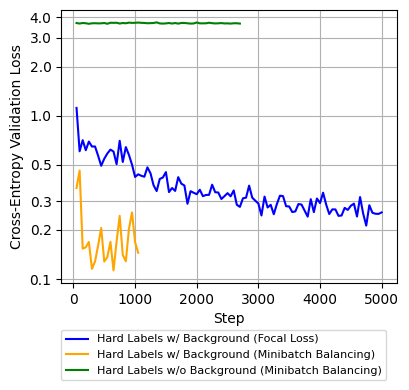

In [87]:
from matplotlib.ticker import ScalarFormatter, FixedLocator, NullLocator

cm = 1 / 2.54
mm = 0.1 * cm

fig, ax = plt.subplots(figsize=(110 * mm, 90 * mm))

step_limit = 5000
for model_name in model_names:
    last_idx = next(
        (
            i
            for i, e in enumerate(histories_per_model[model_name]["steps"])
            if e > step_limit
        ),
        len(histories_per_model[model_name]["steps"]),
    )
    ax.plot(
        histories_per_model[model_name]["steps"][:last_idx],
        histories_per_model[model_name]["eval_loss_ce"][:last_idx],
        label=legend_labels[model_name],
        color=colors[model_name],
    )

ax.set_yscale("log")
yticks = [0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 3.0, 4.0]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="y", style="plain")
ax.grid(True)
ax.set_xlabel("Step")
ax.set_ylabel("Cross-Entropy Validation Loss")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=1,
    fontsize=8,
    frameon=True,
)
plt.show()